In [1]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [2]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from utils import concordance_index, unroll, get_single_task_dataset

In [11]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [3]:
data_path = '/Users/mariana/Documents/projects/Huawei/cloudproject/data/Delays/new_data_b03-09_online/train'

In [4]:
seqs, ts, cs = get_single_task_dataset(4, data_path, horizon=350)

In [5]:
config_path = '../config.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

agent = LambdaSA(config, 42)

In [6]:
# TODO: ts as in baseline

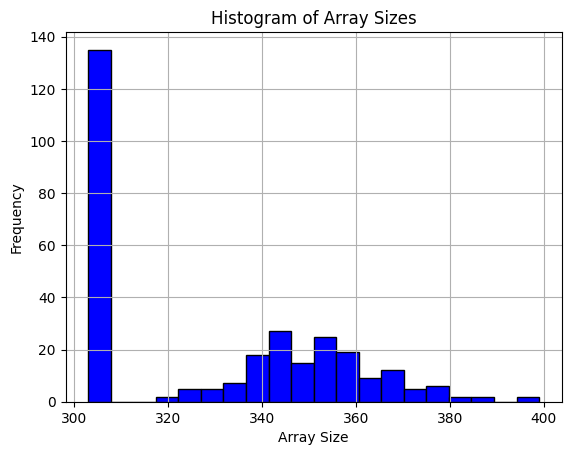

In [6]:
sizes = agent.data['ts']

# Create a histogram of the sizes
plt.hist(sizes, bins=20, color='blue', edgecolor='black')
plt.xlabel('Array Size')
plt.ylabel('Frequency')
plt.title('Histogram of Array Sizes')
plt.grid(True)

# Show the histogram
plt.show()


In [12]:
agent = LambdaSA(config, 42)
agent.lambda_ = 0.0
X_train, X_test, ts_train, ts_test, cs_train, cs_test = agent._get_train_test()
# losses = agent.train(X_train, ts_train, cs_train)

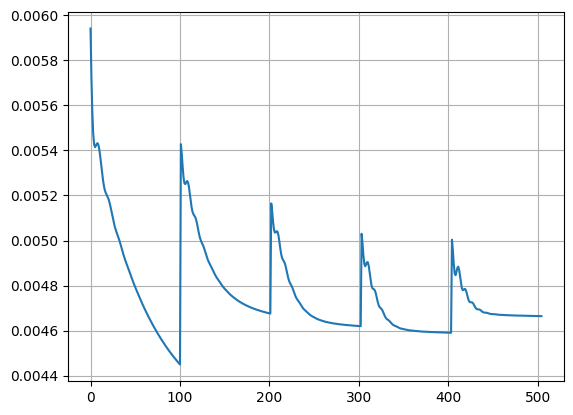

In [13]:
plt.plot(np.hstack(losses))
plt.grid()

In [15]:
X_train.shape

(237, 350, 39)

In [ ]:
%%time

num_exps = 5
sizes = [50, 100, 237]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))
res2_td = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))
res3_td = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    seqs_t, seqs_v, ts_t, ts_v, cs_t, cs_v = agent._get_train_test()
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])
        
        # Initial state.
        model = LambdaSA(config, 42)
        model.train(seqs_t[:size], ts_t[:size], cs_t[:size])
        res2_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Landmarking.
        model = LambdaSA(config, 42)
        model.lambda_ = 1.0
        model.train(seqs_, ts_, cs_)
        res2_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Temporal difference.
        model = LambdaSA(config, 42)
        model.lambda_ = 0.0
        model.train(seqs_, ts_, cs_)
        res2_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_td[fold, i] = concordance_index(scores, ts_v, cs_v)
        
    print()

...